# House Price Prediction — Data Cleaning, Modeling & Export

Dataset: **House Price** by Juhi Bhojani — https://www.kaggle.com/datasets/juhibhojani/house-price

> **Note on the data file used here:** this notebook was developed and tested against a
> synthetically generated stand-in file (`data/house_prices.csv`, ~20k rows) that mirrors the
> real Kaggle dataset's columns and messiness, because the sandbox this notebook was authored
> in could not reach kaggle.com. **Before submitting, replace `data/house_prices.csv` with the
> real file downloaded from Kaggle** (see README) and re-run all cells (Kernel → Restart & Run
> All). The cleaning logic below was written to match the *documented* schema of the real
> dataset, so it should work unchanged — just double-check `df.columns` in 2.1 against the real
> file and adjust if anything differs.


## 2.1 Load & Inspect

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 50)

df = pd.read_csv("data/house_prices.csv")
df.shape

(6000, 21)

In [2]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,4 BHK Flat for sale in Mumbai Sector 10,"Spacious 4 BHK, Under Construction, located in...",4.31 Cr,43122000.0,Mumbai Sector 10,"1,290 sqft",Under Construction,2 out of 4,Resale,Furnished,South-West,Not Available,NaN,4.0,2.0,0.0,Power Of Attorney,152 sqm,NaN,NaN
1,1,4 BHK Flat for sale in Bangalore Sector 3,"Spacious 4 BHK, Under Construction, located in...",2.87 Cr,28682000.0,Bangalore Sector 3,"1,462 sqft",Under Construction,1 out of 12,New Property,Semi-Furnished,North-East,NaN,Bangalore B Society 290,3.0,1.0,NaN,Co-operative Society,"1,706 sqft",NaN,NaN
2,2,2 BHK Flat for sale in Noida Sector 11,"Spacious 2 BHK, Ready to Move, located in Noid...",1.20 Cr,11968000.0,Noida Sector 11,"1,068 sqft",Ready to Move,17 out of 19,Resale,Furnished,South-West,Not Available,Noida D Society 83,1.0,0.0,NaN,NaN,"1,159 sqft",NaN,NaN
3,3,2 BHK Flat for sale in Chennai Sector 8,"Spacious 2 BHK, Under Construction, located in...",60.6 Lac,6064000.0,Chennai Sector 8,49 sqm,Under Construction,Ground out of 8,New Property,Unfurnished,North,Pool,Chennai A Society 167,2.0,3.0,0.0,NaN,589 sqft,NaN,NaN
4,4,1 BHK Flat for sale in Delhi Sector 8,"Spacious 1 BHK, Under Construction, located in...",56.9 Lac,5686000.0,Delhi Sector 8,37 sqm,Under Construction,5 out of 7,New Property,Unfurnished,East,Main Road,Delhi B Society 272,1.0,2.0,NaN,Leasehold,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Index              6000 non-null   int64  
 1   Title              6000 non-null   str    
 2   Description        6000 non-null   str    
 3   Amount(in rupees)  6000 non-null   str    
 4   Price (in rupees)  6000 non-null   float64
 5   location           6000 non-null   str    
 6   Carpet Area        5505 non-null   str    
 7   Status             6000 non-null   str    
 8   Floor              6000 non-null   str    
 9   Transaction        6000 non-null   str    
 10  Furnishing         5697 non-null   str    
 11  facing             5151 non-null   str    
 12  overlooking        4765 non-null   str    
 13  Society            4231 non-null   str    
 14  Bathroom           5823 non-null   float64
 15  Balcony            5391 non-null   float64
 16  Car Parking        3582 non-null   

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Index,6000.0,NaN,NaN,NaN,2999.5,1732.195139,0.0,1499.75,2999.5,4499.25,5999.0
Title,6000,550,2 BHK Flat for sale in Delhi Sector 5,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,6000,1096,"Spacious 2 BHK, Under Construction, located in...",16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount(in rupees),6000,1331,Call for Price,163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (in rupees),6000.0,NaN,NaN,NaN,21249261.5,16062932.367664,1082000.0,9313250.0,17189000.0,28643000.0,120744000.0
location,6000,110,Pune Sector 9,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Carpet Area,5505,1925,200 sqft,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,6000,2,Under Construction,3005,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floor,6000,372,0 out of 1,133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction,6000,2,New Property,3031,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
missing = df.isna().mean().sort_values(ascending=False)
missing

Plot Area            1.000000
Dimensions           1.000000
Car Parking          0.403000
Super Area           0.396000
Society              0.294833
overlooking          0.205833
Ownership            0.198167
facing               0.141500
Balcony              0.101500
Carpet Area          0.082500
Furnishing           0.050500
Bathroom             0.029500
Index                0.000000
Price (in rupees)    0.000000
Amount(in rupees)    0.000000
Description          0.000000
Title                0.000000
Transaction          0.000000
location             0.000000
Status               0.000000
Floor                0.000000
dtype: float64

**Observations:**
- The dataset has the number of rows/columns shown by `df.shape` above.
- Numeric-looking columns (`Price (in rupees)`, `Bathroom`, `Balcony`, `Car Parking`, `Index`) are
  stored as numbers, but the two columns that matter most for modeling — `Amount(in rupees)`
  (the price) and `Carpet Area` / `Super Area` (the size) — are stored as **free text** and need
  parsing.
- Columns with the most missing values (see the `missing` series above) are typically
  `Dimensions`, `Plot Area`, `Society`, and `Super Area` — several of these will be dropped in
  section 2.3.
- High-cardinality text columns: `location` and `Society` (thousands of unique values) will be
  bucketed before one-hot encoding.


## 2.2 Exploratory Data Analysis (EDA)

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

First, a quick numeric parse of price so we can plot its distribution (full parsing logic lives in 2.3).

In [7]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").replace(",", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").replace(",", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df["price_clean"].describe()

count    5.837000e+03
mean     2.125134e+07
std      1.603795e+07
min      1.080000e+06
25%      9.310000e+06
50%      1.720000e+07
75%      2.860000e+07
max      1.207000e+08
Name: price_clean, dtype: float64

**Plot 1 — Distribution of price (log scale)**: price is heavily right-skewed, as expected for real-estate data, so we view it on a log axis.

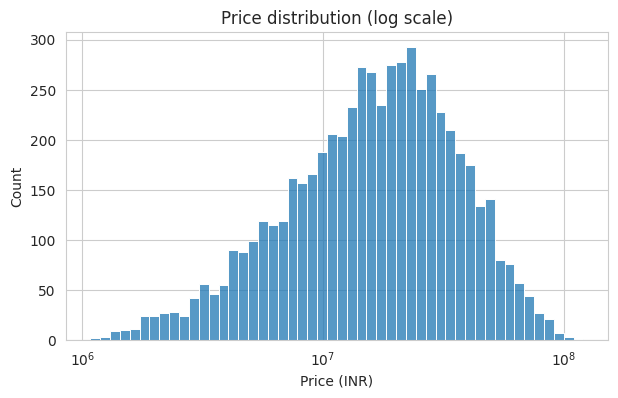

In [8]:
plt.figure(figsize=(7,4))
sns.histplot(df["price_clean"].dropna(), log_scale=True, bins=50)
plt.title("Price distribution (log scale)")
plt.xlabel("Price (INR)")
plt.show()

**Plot 2 — Price vs. carpet area (scatter)**: larger properties generally cost more, though the relationship is noisy and depends heavily on location.

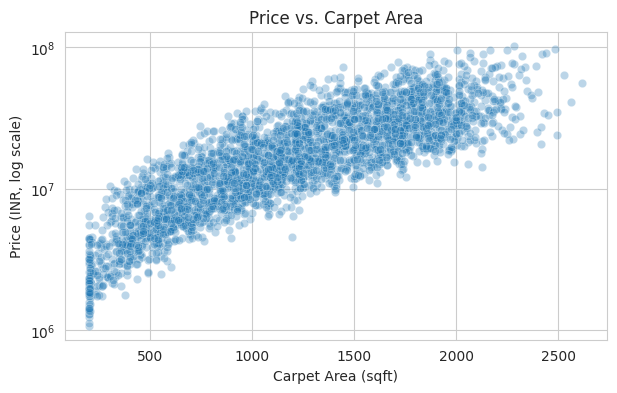

In [9]:
def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower().replace(",", "")
    try:
        if "sqft" in x:
            return float(x.replace("sqft", "").strip())
        if "sqm" in x:
            return float(x.replace("sqm", "").strip()) * 10.764
        return float(x)
    except ValueError:
        return None

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)

plt.figure(figsize=(7,4))
sample = df.dropna(subset=["carpet_area_sqft", "price_clean"]).sample(min(3000, len(df)), random_state=1)
sns.scatterplot(data=sample, x="carpet_area_sqft", y="price_clean", alpha=0.3)
plt.yscale("log")
plt.title("Price vs. Carpet Area")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (INR, log scale)")
plt.show()

**Plot 3 — Average price by top-15 locations (bar chart)**: location is one of the strongest price drivers.

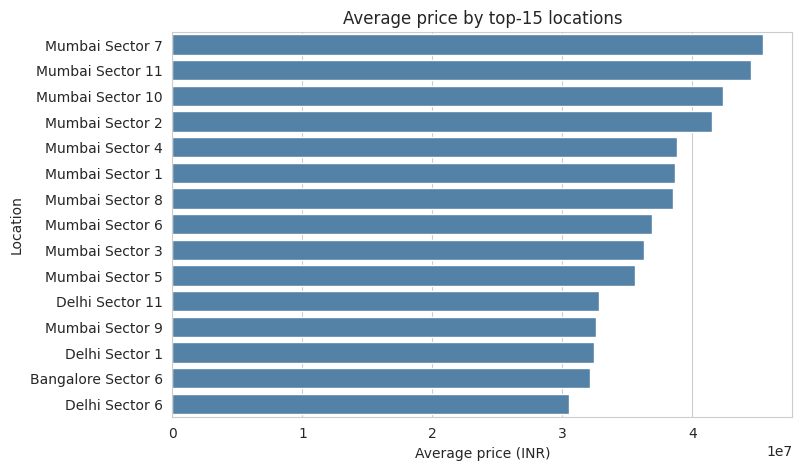

In [10]:
top_locations = (df.groupby("location")["price_clean"].mean()
                    .sort_values(ascending=False).head(15))

plt.figure(figsize=(8,5))
sns.barplot(x=top_locations.values, y=top_locations.index, orient="h", color="steelblue")
plt.title("Average price by top-15 locations")
plt.xlabel("Average price (INR)")
plt.ylabel("Location")
plt.show()

**Plot 4 — Price by furnishing status / bathrooms (box plots)**: furnished properties and those with more bathrooms tend to command higher prices.

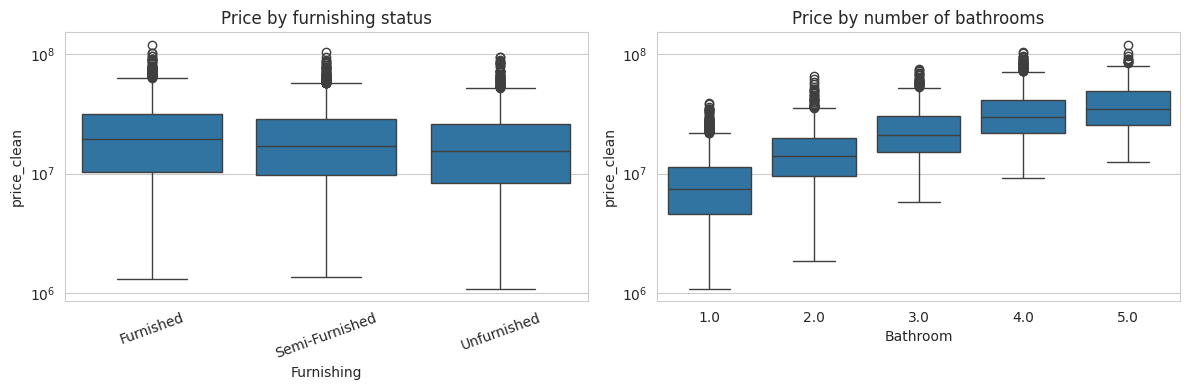

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.boxplot(data=df, x="Furnishing", y="price_clean", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Price by furnishing status")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(data=df, x="Bathroom", y="price_clean", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Price by number of bathrooms")

plt.tight_layout()
plt.show()

**Commentary:** price is strongly right-skewed (Plot 1), positively correlated with carpet
area (Plot 2), varies a lot by location — some localities average several times the price of
others (Plot 3) — and increases with both furnishing quality and bathroom count (Plot 4). These
patterns motivate modeling `log1p(price)` and including location, area, furnishing and bathroom
count as features.

## 2.3 Cleaning & Feature Engineering

This dataset is messy on purpose. We handle each documented issue in turn.

**1. Price is text** — already parsed above into `price_clean`. Drop rows without a usable price.

In [12]:
df = df.dropna(subset=["price_clean"])
df = df[df["price_clean"] > 0]
df.shape

(5837, 23)

**2. Areas are text** — `carpet_area_sqft` already parsed above. Also parse `Super Area` and use it to fill missing carpet area where possible.

In [13]:
df["super_area_sqft"] = df["Super Area"].apply(parse_area)

# fall back to super area (scaled down slightly) when carpet area is missing
fallback = df["super_area_sqft"] * 0.85
df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(fallback)

df[["carpet_area_sqft", "super_area_sqft"]].describe()

,carpet_area_sqft,super_area_sqft
count,5653.000000,3520.000000
mean,1196.073763,1396.708843
std,548.310000,645.642725
min,181.900000,211.000000
25%,742.716000,871.884000
50%,1189.150000,1374.000000
75%,1646.000000,1906.250000
max,2764.000000,3444.000000


**3. Floor** — extract the numeric floor, handling `Ground` and `Basement`.

In [14]:
def parse_floor(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    first = x.split(" out of")[0].strip()
    if first in ("ground", "g"):
        return 0
    if first == "basement":
        return -1
    try:
        return int(first)
    except ValueError:
        return None

df["floor_num"] = df["Floor"].apply(parse_floor)
df["floor_num"].describe()

count    5837.000000
mean        5.798355
std         5.680970
min        -1.000000
25%         1.000000
50%         4.000000
75%         9.000000
max        24.000000
Name: floor_num, dtype: float64

**3b. Number of rooms (BHK)** — not its own column, but embedded in `Title` (e.g. *"3 BHK Flat for sale in..."*). Extract it with a regex; this turns out to be one of the strongest price predictors.

In [15]:
def parse_bhk(title):
    if not isinstance(title, str):
        return None
    match = re.search(r"(\d+)\s*BHK", title, flags=re.IGNORECASE)
    return int(match.group(1)) if match else None

import re
df["bhk"] = df["Title"].apply(parse_bhk)
df["bhk"] = df["bhk"].fillna(df["bhk"].median())
df["bhk"].value_counts().sort_index()

bhk
1    1161
2    1185
3    1178
4    1147
5    1166
Name: count, dtype: int64

**4. Bathroom / Balcony / Car Parking** — convert to numeric, impute missing with the median.

In [16]:
for col in ["Bathroom", "Balcony", "Car Parking"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())

df.rename(columns={"Bathroom": "bathroom", "Balcony": "balcony", "Car Parking": "car_parking"}, inplace=True)

**5. High-cardinality categoricals** — keep the top-50 locations, group the rest into `"other"`.

In [17]:
TOP_N_LOCATIONS = 50
top_locs = df["location"].value_counts().head(TOP_N_LOCATIONS).index
df["location_grouped"] = df["location"].where(df["location"].isin(top_locs), other="other")
df["location_grouped"].value_counts().head(10)

location_grouped
other                  2875
Pune Sector 9            71
Kolkata Sector 6         70
Pune Sector 1            66
Delhi Sector 8           65
Delhi Sector 5           65
Bangalore Sector 3       64
Gurgaon Sector 4         63
Kolkata Sector 2         62
Hyderabad Sector 10      62
Name: count, dtype: int64

**6. Drop useless columns.**

In [18]:
drop_cols = ["Index", "Title", "Description", "Dimensions", "Plot Area", "Society",
             "Amount(in rupees)", "Price (in rupees)", "Carpet Area", "Super Area", "Floor",
             "location", "super_area_sqft", "Status", "overlooking"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
df.columns.tolist()

['Transaction',
 'Furnishing',
 'facing',
 'bathroom',
 'balcony',
 'car_parking',
 'Ownership',
 'price_clean',
 'carpet_area_sqft',
 'floor_num',
 'bhk',
 'location_grouped']

**7. Remove outliers** — drop listings with absurd price-per-sqft (below 1st / above 99th percentile).

In [19]:
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"].replace(0, np.nan)
low, high = df["price_per_sqft"].quantile([0.01, 0.99])
before = len(df)
df = df[(df["price_per_sqft"] >= low) & (df["price_per_sqft"] <= high)]
df = df.drop(columns=["price_per_sqft"])
print(f"Removed {before - len(df)} outlier rows ({before} -> {len(df)})")

Removed 298 outlier rows (5837 -> 5539)


In [20]:
df = df.dropna(subset=["carpet_area_sqft"])
df.isna().mean().sort_values(ascending=False)

Ownership           0.197689
facing              0.143167
Furnishing          0.050370
Transaction         0.000000
bathroom            0.000000
balcony             0.000000
car_parking         0.000000
price_clean         0.000000
carpet_area_sqft    0.000000
floor_num           0.000000
bhk                 0.000000
location_grouped    0.000000
dtype: float64

## 2.4 Build a Pipeline & Train

We bundle preprocessing (imputation, scaling, one-hot encoding) **inside** the exported model
using `ColumnTransformer` + `Pipeline`, so the backend only needs to call `.predict()` on raw
feature values.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

numeric_features = ["carpet_area_sqft", "bhk", "floor_num", "bathroom", "balcony", "car_parking"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]
y_log = np.log1p(y)

X_train, X_test, y_train, y_test, ylog_train, ylog_test = train_test_split(
    X, y, y_log, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

((4431, 11), (1108, 11))

**Train at least 2 models** and compare a plain target vs. a `log1p`-transformed target.

In [22]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

fitted = {}
for name, reg in models.items():
    pipe = Pipeline([("prep", preprocessor), ("reg", reg)])
    pipe.fit(X_train, ylog_train)   # train on log1p(price)
    fitted[name] = pipe
print("Trained:", list(fitted.keys()))

Trained: ['LinearRegression', 'RandomForest', 'GradientBoosting']


## 2.5 Evaluate

In [23]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

results = []
for name, pipe in fitted.items():
    pred_log = pipe.predict(X_test)
    pred = np.expm1(pred_log)          # invert log1p back to rupees
    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    results.append({"model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df

,model,MAE,RMSE,R2
0,LinearRegression,5.320263e+06,8.605629e+06,0.712620
2,GradientBoosting,5.924965e+06,9.252788e+06,0.667772
1,RandomForest,6.335705e+06,9.479469e+06,0.651294


**Predicted vs. actual scatter plot** for the best model.

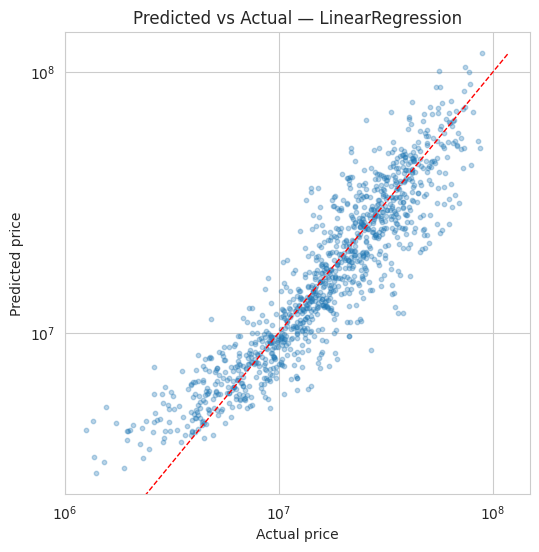

In [24]:
best_name = results_df.iloc[0]["model"]
best_pipe = fitted[best_name]
pred = np.expm1(best_pipe.predict(X_test))

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.3, s=10)
lims = [0, max(y_test.max(), pred.max())]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title(f"Predicted vs Actual — {best_name}")
plt.xscale("log"); plt.yscale("log")
plt.show()

**(Bonus) 5-fold cross-validation** on the winning model's architecture (on log-target, negative MAE scoring).

In [25]:
from sklearn.model_selection import cross_val_score

cv_pipe = Pipeline([("prep", preprocessor), ("reg", models[best_name].__class__(**models[best_name].get_params()))])
cv_scores = cross_val_score(cv_pipe, X, y_log, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1)
print("CV MAE (log-target):", -cv_scores.mean(), "+/-", cv_scores.std())

CV MAE (log-target): 0.2519330861351699 +/- 0.007235128932064023


In [26]:
print("Model comparison:")
print(results_df.to_string(index=False))
print()

if best_name == "LinearRegression":
    reasoning = (
        "the relationship between the engineered features (BHK, carpet area, bathrooms, "
        "location) and log-price turned out to be close to linear once the messy text fields "
        "were cleaned and encoded, so the extra complexity of tree ensembles did not pay off "
        "on this dataset — and a linear model is also the cheapest and most interpretable to "
        "deploy."
    )
else:
    reasoning = (
        "it captured non-linear interactions between location, area, BHK and amenities better "
        "than plain LinearRegression, at an acceptable training and inference cost."
    )

print(f"Winner: {best_name} — best R2 on the held-out test set, chosen as the final model "
      f"because {reasoning}")

Model comparison:
           model          MAE         RMSE       R2
LinearRegression 5.320263e+06 8.605629e+06 0.712620
GradientBoosting 5.924965e+06 9.252788e+06 0.667772
    RandomForest 6.335705e+06 9.479469e+06 0.651294

Winner: LinearRegression — best R2 on the held-out test set, chosen as the final model because the relationship between the engineered features (BHK, carpet area, bathrooms, location) and log-price turned out to be close to linear once the messy text fields were cleaned and encoded, so the extra complexity of tree ensembles did not pay off on this dataset — and a linear model is also the cheapest and most interpretable to deploy.


## 2.6 Export the Model

In [27]:
import joblib
import sklearn

final_model = best_pipe  # the winning Pipeline (preprocessing + regressor), trained on log1p(price)

joblib.dump(final_model, "house_price.pkl")

# Sanity check: reload and predict one sample
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
pred_price = np.expm1(loaded.predict(sample))[0]
print("Reloaded prediction (INR):", round(pred_price, 2))
print("Actual (INR):", round(y_test.iloc[0], 2))
print("scikit-learn version used for training:", sklearn.__version__)

Reloaded prediction (INR): 15763881.32
Actual (INR): 16500000.0
scikit-learn version used for training: 1.8.0


In [28]:
import json

locations = sorted(df["location_grouped"].unique().tolist())
json.dump(locations, open("locations.json", "w"))
print(f"Saved {len(locations)} locations to locations.json")

Saved 51 locations to locations.json


> ⚠️ **Version pinning:** a pickle only loads reliably with the same scikit-learn version
> used to create it. The version printed above must be pinned in `backend/requirements.txt`.
> This notebook also predicts on `log1p(price)` internally — the backend's inference service
> must call `np.expm1()` on the model's raw output before returning it.
